<a href="https://colab.research.google.com/github/nicholastimmann-cyber/Travel_Tide_CustomerSegmentation/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#loading of df for PCA
directory = "/content/drive/MyDrive/Colab Notebooks"

df_users = pd.read_csv(f'{directory}/user_base.csv', index_col="user_id")
print(df_users.columns)
print(df_users.shape)
df_users.head()

Index(['num_sessions', 'avg_session_duration', 'std_session_duration',
       'avg_clicks', 'bookings', 'canceled_trips', 'num_trips', 'destinations',
       'avg_checked_bags', 'avg_seats', 'avg_nights', 'avg_rooms',
       'std_nights', 'num_flights', 'num_hotels',
       'total_money_spent_per_flight', 'avg_money_spent_per_flight',
       'avg_money_spent_per_seat', 'total_money_spent_per_hotel',
       'avg_money_spent_per_hotel', 'avg_time_after_booking',
       'avg_distance_km', 'avg_price_per_km', 'summer', 'spring', 'fall',
       'winter', 'gender', 'married', 'has_children', 'home_country', 'age'],
      dtype='object')
(5998, 32)


,num_sessions,avg_session_duration,std_session_duration,avg_clicks,bookings,canceled_trips,num_trips,destinations,avg_checked_bags,avg_seats,...,avg_price_per_km,summer,spring,fall,winter,gender,married,has_children,home_country,age
user_id,,,,,,,,,,,,,,,,,,,,,
23557,8,76.625,68.783174,10.250,2,0.0,2.0,0.0,NaN,NaN,...,NaN,1.0,1.0,0.0,0.0,F,True,False,usa,67.260274
94883,8,67.750,70.241929,9.125,2,0.0,2.0,2.0,0.5,1.5,...,0.290667,0.0,2.0,0.0,0.0,F,True,False,usa,53.980822
101486,8,122.250,55.943211,16.375,2,0.0,2.0,1.0,0.0,1.0,...,0.196728,2.0,0.0,0.0,0.0,F,True,True,usa,53.252055
101961,8,117.750,59.796679,15.750,5,0.0,5.0,5.0,0.4,1.0,...,0.179108,1.0,3.0,0.0,1.0,F,True,False,usa,45.476712
106907,8,241.500,274.650427,30.000,1,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,F,True,True,usa,47.304110


In [ ]:
#Filling NA values with a 0
df_users.fillna(0,inplace=True)

In [ ]:
# tranformation of binary values into 0 and 1
df_users["gender"] = df_users["gender"].map({"F": 0, "M": 1, "O":2})
df_users["married"] = df_users["married"].astype(int)
df_users["has_children"] = df_users["has_children"].astype(int)

In [ ]:
#keep home_country as a feature
print('Unterschiedliche Länder', df_users["home_country"].nunique())

df_users["home_country"] = (df_users["home_country"] == 'usa').astype("int")

Unterschiedliche Länder 2


In [ ]:
df_users.head()

,num_sessions,avg_session_duration,std_session_duration,avg_clicks,bookings,canceled_trips,num_trips,destinations,avg_checked_bags,avg_seats,...,avg_price_per_km,summer,spring,fall,winter,gender,married,has_children,home_country,age
user_id,,,,,,,,,,,,,,,,,,,,,
23557,8,76.625,68.783174,10.250,2,0.0,2.0,0.0,0.0,0.0,...,0.000000,1.0,1.0,0.0,0.0,0,1,0,1,67.260274
94883,8,67.750,70.241929,9.125,2,0.0,2.0,2.0,0.5,1.5,...,0.290667,0.0,2.0,0.0,0.0,0,1,0,1,53.980822
101486,8,122.250,55.943211,16.375,2,0.0,2.0,1.0,0.0,1.0,...,0.196728,2.0,0.0,0.0,0.0,0,1,1,1,53.252055
101961,8,117.750,59.796679,15.750,5,0.0,5.0,5.0,0.4,1.0,...,0.179108,1.0,3.0,0.0,1.0,0,1,0,1,45.476712
106907,8,241.500,274.650427,30.000,1,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0,1,1,1,47.304110


In [ ]:
#Filling NA values with a 0
print(df_users.isnull().sum())

# drop gender NaN
#df_users["gender"].dropna(inplace=True)

df_users.fillna(0, inplace=True)

num_sessions                    0
avg_session_duration            0
std_session_duration            0
avg_clicks                      0
bookings                        0
canceled_trips                  0
num_trips                       0
destinations                    0
avg_checked_bags                0
avg_seats                       0
avg_nights                      0
avg_rooms                       0
std_nights                      0
num_flights                     0
num_hotels                      0
total_money_spent_per_flight    0
avg_money_spent_per_flight      0
avg_money_spent_per_seat        0
total_money_spent_per_hotel     0
avg_money_spent_per_hotel       0
avg_time_after_booking          0
avg_distance_km                 0
avg_price_per_km                0
summer                          0
spring                          0
fall                            0
winter                          0
gender                          0
married                         0
has_children  

In [ ]:
print(df_users.isnull().sum())

num_sessions                    0
avg_session_duration            0
std_session_duration            0
avg_clicks                      0
bookings                        0
canceled_trips                  0
num_trips                       0
destinations                    0
avg_checked_bags                0
avg_seats                       0
avg_nights                      0
avg_rooms                       0
std_nights                      0
num_flights                     0
num_hotels                      0
total_money_spent_per_flight    0
avg_money_spent_per_flight      0
avg_money_spent_per_seat        0
total_money_spent_per_hotel     0
avg_money_spent_per_hotel       0
avg_time_after_booking          0
avg_distance_km                 0
avg_price_per_km                0
summer                          0
spring                          0
fall                            0
winter                          0
gender                          0
married                         0
has_children  

In [ ]:
from sklearn.preprocessing import StandardScaler

# scaling of data for the PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_users)
customers_scaled = pd.DataFrame(X_scaled)
customers_scaled.index = df_users.index
customers_scaled.columns = df_users.columns

In [ ]:
customers_scaled.head(2)

,num_sessions,avg_session_duration,std_session_duration,avg_clicks,bookings,canceled_trips,num_trips,destinations,avg_checked_bags,avg_seats,...,avg_price_per_km,summer,spring,fall,winter,gender,married,has_children,home_country,age
user_id,,,,,,,,,,,,,,,,,,,,,
23557,-0.443872,-0.980898,-0.500767,-1.003398,-0.449772,-0.327625,-0.379843,-1.461063,-1.031075,-1.810113,...,-1.772119,0.829609,-0.171064,-0.073237,-1.074945,-0.362212,1.127054,-0.696171,0.449181,1.931553
94883,-0.443872,-1.153894,-0.478750,-1.174941,-0.449772,-0.327625,-0.379843,-0.055311,0.028247,0.911810,...,1.252566,-0.738128,0.858064,-0.073237,-1.074945,-0.362212,1.127054,-0.696171,0.449181,0.829604


17 Components var_exp = 0.93

In [ ]:
# Explaining 93% of the data
var_exp = 0.93
pca_93 = PCA(n_components=var_exp, random_state=42)
customers_pca_93 = pca_93.fit_transform(customers_scaled)

customers_pca_93 = pd.DataFrame(customers_pca_93)
customers_pca_93.index = customers_scaled.index
customers_pca_93.index.name = "user_id"
customers_pca_93.columns = [f"pca_{i}" for i in range(customers_pca_93.shape[1])]

customers_pca_93.to_csv(f'{directory}/user_pca_0.93.csv')

print(customers_pca_93.shape)
customers_pca_93.head()


(5998, 17)


,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14,pca_15,pca_16
user_id,,,,,,,,,,,,,,,,,
23557,-2.276954,-0.280549,-3.994869,3.351051,1.353663,-2.158080,0.439640,-1.096351,0.283748,0.768888,-0.387076,-0.350768,-0.583932,0.785300,-0.504646,2.163029,-0.776706
94883,-0.424352,-1.658170,0.250756,-1.135979,1.647112,1.349490,-0.212745,-0.873587,0.116600,0.918659,-0.909389,-0.768912,1.202748,-0.266835,-0.058627,0.518649,0.415329
101486,-1.287191,-0.382120,-1.005654,0.828737,1.798240,0.309894,0.613401,-0.949464,0.423852,0.459181,1.769316,-0.123174,-1.489643,-1.907205,0.211602,0.633302,-0.135858
101961,3.112392,0.683799,-2.300496,-1.855919,0.267935,-0.750818,0.214058,-0.437059,0.166973,0.986444,-0.120315,-0.810117,0.552955,-0.060158,0.377945,0.104290,0.921921
106907,-4.985648,4.754590,2.781044,0.489885,1.270154,-1.434827,0.540270,0.750844,0.074372,0.149019,0.810504,-0.945046,-0.266898,-0.370588,-0.115816,-0.041864,0.500413


In [ ]:
# Show Eigenvalues
component_matrix = pd.DataFrame(pca.components_).T
component_matrix.columns = [f"pca_{i}"for i in range(component_matrix.shape[1])]
component_matrix.index = customers_scaled.columns
component_matrix

,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,...,pca_22,pca_23,pca_24,pca_25,pca_26,pca_27,pca_28,pca_29,pca_30,pca_31
num_sessions,0.017377,0.006181,0.005859,-0.004649,0.133741,-0.122673,-0.641840,0.053210,0.163467,-0.049637,...,-0.016745,-0.007708,-0.000885,0.000050,-0.002421,-0.003828,0.004766,0.001247,8.107475e-16,-0.000000e+00
avg_session_duration,0.115646,0.426395,0.221712,0.114401,-0.004588,-0.024639,0.018868,-0.009192,-0.006219,0.023987,...,-0.260721,-0.019978,-0.004746,0.008863,-0.003307,0.002019,0.753535,0.000320,4.085068e-14,-7.052545e-15
std_session_duration,0.017806,0.401984,0.284777,0.174450,0.026120,0.002422,-0.011865,-0.006350,0.012209,0.005094,...,0.842667,0.017742,0.005139,-0.003909,-0.003880,0.024068,-0.046504,-0.002897,-7.636654e-15,6.808435e-16
avg_clicks,0.124857,0.414731,0.208568,0.106052,-0.006979,-0.022495,0.022702,-0.012280,-0.003440,0.029121,...,-0.324708,-0.042825,-0.031413,-0.004502,0.011562,-0.026926,-0.650108,0.001010,-3.006188e-14,6.633936e-15
bookings,0.308870,0.155953,-0.117563,-0.090759,-0.036365,-0.067912,-0.000109,0.043993,-0.011076,0.014583,...,0.010570,-0.114467,-0.273665,-0.092707,0.063200,-0.053170,-0.009570,0.001095,7.190171e-01,-3.732655e-01
canceled_trips,-0.017224,0.366568,0.275999,0.169613,0.023875,-0.016369,-0.038596,0.005095,0.005896,-0.007341,...,-0.304443,0.054638,0.079063,0.020063,-0.014674,0.007347,-0.080159,0.000459,-1.467519e-01,7.618373e-02
num_trips,0.309888,0.080488,-0.172505,-0.124374,-0.040908,-0.064054,0.007707,0.042609,-0.012181,0.015953,...,0.072126,-0.124615,-0.287485,-0.096028,0.065666,-0.054232,0.006737,0.000993,-6.778560e-01,-4.650092e-01
destinations,0.294474,0.073014,-0.089268,-0.223106,-0.023346,-0.019458,0.007213,0.038545,-0.016357,0.033664,...,-0.014660,0.124876,0.109245,0.459230,0.273427,-0.462827,0.001305,-0.011617,3.933898e-14,-1.679903e-14
avg_checked_bags,0.138043,-0.087577,0.106903,0.022913,0.124716,0.282473,0.039884,0.078105,-0.093596,0.199695,...,-0.000352,-0.013527,0.008013,-0.004262,-0.012271,-0.001973,0.000986,-0.000594,-1.587295e-16,-3.926450e-16
avg_seats,0.245161,-0.134323,0.147151,0.053232,0.128356,0.416724,-0.057480,-0.008829,-0.028560,0.071059,...,-0.011751,0.006072,0.062492,-0.065551,0.481278,0.287564,0.000690,0.457249,1.592306e-14,1.265688e-14


This code can be used to look at the plot of the different data frames with 90,93 and 95% var_exp

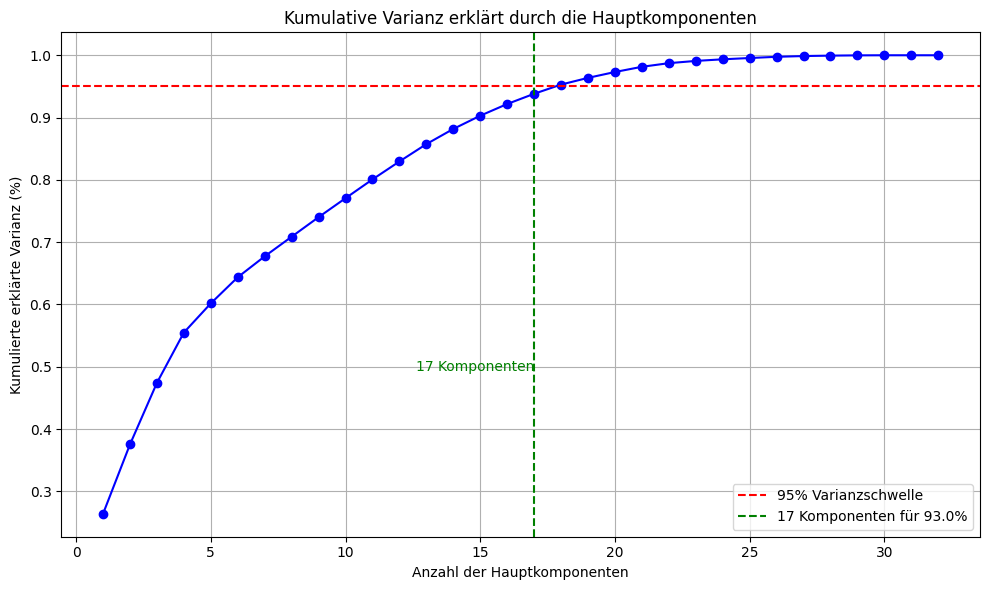

In [ ]:
# Step 3: Perform the PCA. We set n_components to None in order to calculate the variance of all possible principal components.
pca = PCA(n_components=None, random_state= 42)
pca.fit(X_scaled)

# Step 4: Calculate the cumulative variance
# The 'explained_variance_ratio_' indicates the percentage of variance
# explained by each principal component.
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Step 5: Create the plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='b')
plt.title('Kumulative Varianz erklärt durch die Hauptkomponenten')
plt.xlabel('Anzahl der Hauptkomponenten')
plt.ylabel('Kumulierte erklärte Varianz (%)')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianzschwelle')

# Den Punkt finden, an dem die kumulierte Varianz 95% überschreitet
n_components_95 = np.where(cumulative_variance >= var_exp)[0][0] + 1
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Komponenten für {var_exp * 100}%')
plt.text(n_components_95, 0.5, f'{n_components_95} Komponenten', color='g', ha='right', va='center')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
cumulative_variance

array([0.26392532, 0.37526751, 0.47411707, 0.55486007, 0.60169837,
       0.6436611 , 0.67719241, 0.70867614, 0.74009151, 0.77053424,
       0.80068552, 0.82947936, 0.85735062, 0.88171306, 0.90294777,
       0.92174298, 0.93815669, 0.95295779, 0.9637163 , 0.97310523,
       0.98147784, 0.98730149, 0.990914  , 0.99349476, 0.99556633,
       0.99752526, 0.99872929, 0.9994047 , 0.99983927, 1.        ,
       1.        , 1.        ])

Nun schauen wir uns an welche Variablen Kombinantion am meisten zu unserem Komponentenwert beiträgt. So verstehen wir unsere Kompenenten etwas besser

<Axes: >

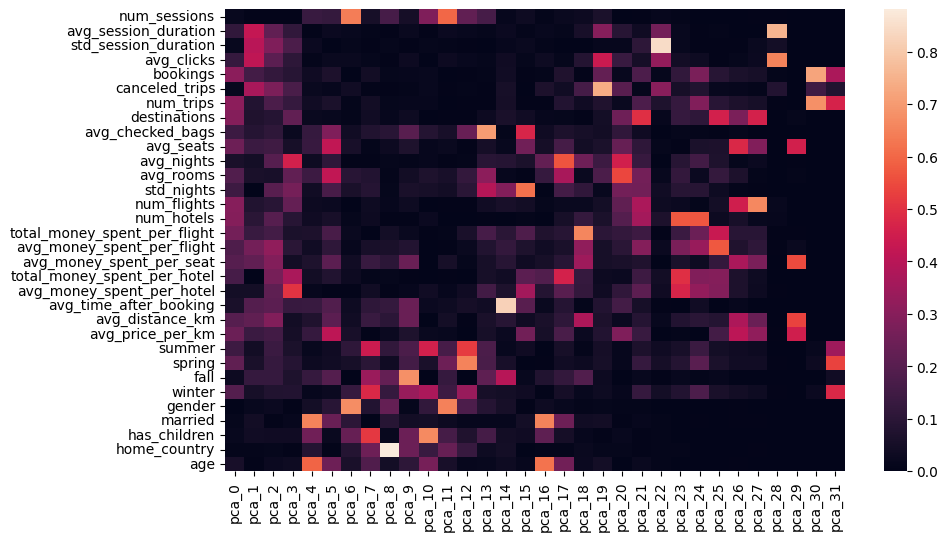

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(np.abs(component_matrix))

PCA with 95% Variance explained

In [ ]:
# Explaining 95% of the data
var_exp = 0.95
pca_95 = PCA(n_components=var_exp, random_state=42)
customers_pca_95 = pca_95.fit_transform(customers_scaled)

customers_pca_95 = pd.DataFrame(customers_pca_95)

# correct dataframe name and correct attributes
customers_pca_95.index = customers_scaled.index
customers_pca_95.index.name = "user_id"
customers_pca_95.columns = [f"pca_{i}" for i in range(customers_pca_95.shape[1])]

customers_pca_95.to_csv(f'{directory}/user_pca.csv.0.95')

print(customers_pca_95.shape)
customers_pca_95.head()

(5998, 18)


,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14,pca_15,pca_16,pca_17
user_id,,,,,,,,,,,,,,,,,,
23557,-2.276954,-0.280549,-3.994869,3.351051,1.353663,-2.158080,0.439640,-1.096351,0.283748,0.768888,-0.387076,-0.350768,-0.583932,0.785300,-0.504646,2.163029,-0.776706,0.430427
94883,-0.424352,-1.658170,0.250756,-1.135979,1.647112,1.349490,-0.212745,-0.873587,0.116600,0.918659,-0.909389,-0.768912,1.202748,-0.266835,-0.058627,0.518649,0.415329,0.005887
101486,-1.287191,-0.382120,-1.005654,0.828737,1.798240,0.309894,0.613401,-0.949464,0.423852,0.459181,1.769316,-0.123174,-1.489643,-1.907205,0.211602,0.633302,-0.135858,0.143465
101961,3.112392,0.683799,-2.300496,-1.855919,0.267935,-0.750818,0.214058,-0.437059,0.166973,0.986444,-0.120315,-0.810117,0.552955,-0.060158,0.377945,0.104290,0.921921,0.499585
106907,-4.985648,4.754590,2.781044,0.489885,1.270154,-1.434827,0.540270,0.750844,0.074372,0.149019,0.810504,-0.945046,-0.266898,-0.370588,-0.115816,-0.041864,0.500413,-0.645973


In [ ]:
#Explaining 90% of the data
var_exp = 0.9
pca_90 = PCA(n_components = var_exp, random_state= 42)
customers_pca_90 = pca_90.fit_transform(customers_scaled)


customers_pca_90 = pd.DataFrame(customers_pca_90)

customers_pca_90.index = customers_scaled.index
customers_pca_90.index.name = "user_id"
customers_pca_90.columns = [f"pca_{i}"for i in range(customers_pca_90.shape[1])]

customers_pca_90.to_csv(f'{directory}/user_pca.csv.0.90')

print(customers_pca_90.shape)
customers_pca_90.head()

(5998, 15)


,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14
user_id,,,,,,,,,,,,,,,
23557,-2.276954,-0.280549,-3.994869,3.351051,1.353663,-2.158080,0.439640,-1.096351,0.283748,0.768888,-0.387076,-0.350768,-0.583932,0.785300,-0.504646
94883,-0.424352,-1.658170,0.250756,-1.135979,1.647112,1.349490,-0.212745,-0.873587,0.116600,0.918659,-0.909389,-0.768912,1.202748,-0.266835,-0.058627
101486,-1.287191,-0.382120,-1.005654,0.828737,1.798240,0.309894,0.613401,-0.949464,0.423852,0.459181,1.769316,-0.123174,-1.489643,-1.907205,0.211602
101961,3.112392,0.683799,-2.300496,-1.855919,0.267935,-0.750818,0.214058,-0.437059,0.166973,0.986444,-0.120315,-0.810117,0.552955,-0.060158,0.377945
106907,-4.985648,4.754590,2.781044,0.489885,1.270154,-1.434827,0.540270,0.750844,0.074372,0.149019,0.810504,-0.945046,-0.266898,-0.370588,-0.115816
